Dataset Loaded Successfully
Transactions: 9994
Orders: 5009
Products: 1841

First Five Records
         Order ID                                       Product Name
0  CA-2011-103800  Message Book, Wirebound, Four 5 1/2" X 4" Form...
1  CA-2011-112326                                          Avery 508
2  CA-2011-112326                      SAFCO Boltless Steel Shelving
3  CA-2011-112326         GBC Standard Plastic Binding Systems Combs
4  CA-2011-141817  Avery Hi-Liter EverBold Pen Style Fluorescent ...

Unique Product Pairs: 9835

Top 10 Product Pairs
                                        Product Pair  CoOccurrence
0                (Hon Olson Stacker Chairs, Staples)             3
1        (Satellite Sectional Post Binders, Staples)             3
2  (#10 White Business Envelopes,4 1/8 x 9 1/2, S...             3
3  (Hoover Shoulder Vac Commercial Portable Vacuu...             3
4                               (Newell 34, Staples)             3
5              (KI Adjustable-Height Ta

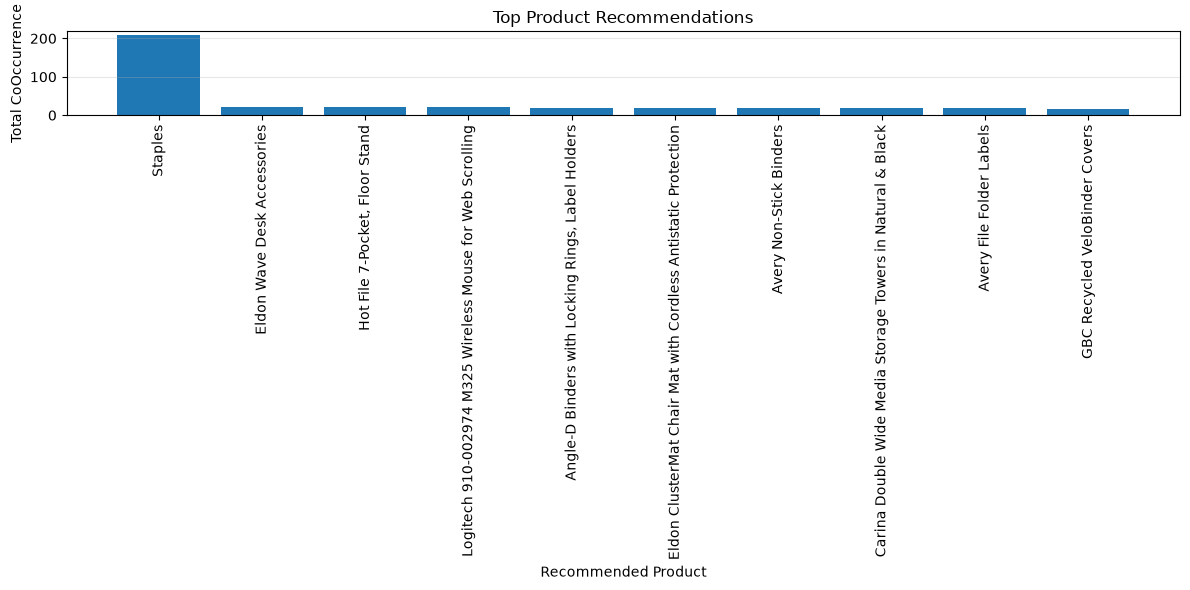


DAY 7 COMPLETED SUCCESSFULLY

Recommendation Engine Improvements
✓ Recommendations ranked by CoOccurrence
✓ Products sorted from strongest to weakest association
✓ Top 5 recommendations retained for every product
✓ Same sales dataset reused
✓ Improved over Week 2 recommendation logic

Recommendation Engine Ready for API Integration.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("../../week1/preprocessing/cleaned_dataset.csv")

df = df[["Order ID", "Product Name"]]

df = df.dropna()

print("Dataset Loaded Successfully")
print("Transactions:", len(df))
print("Orders:", df["Order ID"].nunique())
print("Products:", df["Product Name"].nunique())

print("\nFirst Five Records")
print(df.head())

# ==========================================================
# CREATE SHOPPING BASKETS
# ==========================================================

baskets = (
    df.groupby("Order ID")["Product Name"]
      .apply(lambda x: list(set(x)))
      .reset_index(name="Products")
)

# ==========================================================
# GENERATE PRODUCT PAIRS
# ==========================================================

pair_counter = Counter()

for basket in baskets["Products"]:

    if len(basket) < 2:
        continue

    basket = sorted(basket)

    for pair in combinations(basket, 2):
        pair_counter[pair] += 1

print("\nUnique Product Pairs:", len(pair_counter))

# ==========================================================
# CREATE PAIR DATAFRAME
# ==========================================================

pair_df = pd.DataFrame(
    pair_counter.items(),
    columns=[
        "Product Pair",
        "CoOccurrence"
    ]
)

pair_df = pair_df.sort_values(
    by="CoOccurrence",
    ascending=False
).reset_index(drop=True)

print("\nTop 10 Product Pairs")
print(pair_df.head(10))

# ==========================================================
# BUILD RECOMMENDATION TABLE
# ==========================================================

recommendations = []

for _, row in pair_df.iterrows():

    product1 = row["Product Pair"][0]
    product2 = row["Product Pair"][1]
    score = row["CoOccurrence"]

    recommendations.append(
        {
            "Product Name": product1,
            "Recommended Product": product2,
            "CoOccurrence": score,
        }
    )

    recommendations.append(
        {
            "Product Name": product2,
            "Recommended Product": product1,
            "CoOccurrence": score,
        }
    )

recommendation_df = pd.DataFrame(recommendations)

recommendation_df = recommendation_df.sort_values(
    by=[
        "Product Name",
        "CoOccurrence"
    ],
    ascending=[
        True,
        False
    ]
)

recommendation_df = recommendation_df.drop_duplicates(
    subset=[
        "Product Name",
        "Recommended Product"
    ]
)

recommendation_df = recommendation_df.groupby(
    "Product Name",
    group_keys=False
).head(5)

recommendation_df = recommendation_df.reset_index(drop=True)

print("\nRecommendation Summary")

print("Total Products:",
      recommendation_df["Product Name"].nunique())

print("Total Recommendations:",
      len(recommendation_df))

print("Highest CoOccurrence:",
      recommendation_df["CoOccurrence"].max())

print("Lowest CoOccurrence:",
      recommendation_df["CoOccurrence"].min())

print("\nTop 20 Recommendations")
print(recommendation_df.head(20))

# ==========================================================
# RECOMMENDATION STATISTICS
# ==========================================================

print("\nRecommendations Per Product")

print(
    recommendation_df
    .groupby("Product Name")
    .size()
    .describe()
)

# ==========================================================
# SAVE RECOMMENDATIONS
# ==========================================================

recommendation_df.to_csv(
    "product_recommendations.csv",
    index=False
)

print("Rows:", len(recommendation_df))

# ==========================================================
# WEEK 2 VS WEEK 3 COMPARISON
# ==========================================================

comparison = pd.DataFrame(
    {
        "Feature": [
            "Recommendation Method",
            "Ranking",
            "Purchase Frequency Used",
            "Weak Recommendations",
            "Top Recommendations Returned",
            "Recommendation Score",
        ],
        "Week 2": [
            "Product Pair Frequency",
            "No",
            "Limited",
            "Included",
            "All",
            "Pair Count",
        ],
        "Week 3": [
            "Co-occurrence Frequency",
            "Yes",
            "Yes",
            "Ranked Lower",
            "Top 5",
            "CoOccurrence",
        ],
    }
)

print("\n======================================")
print("WEEK 2 VS WEEK 3")
print("======================================")

print(comparison.to_string(index=False))

comparison.to_csv(
    "week2_vs_week3_comparison.csv",
    index=False
)


# ==========================================================
# MODEL SUMMARY
# ==========================================================

print("\n======================================")
print("MODEL SUMMARY")
print("======================================")

print("Unique Products Covered :",
      recommendation_df["Product Name"].nunique())

print("Total Recommendations :",
      len(recommendation_df))

print("Maximum CoOccurrence :",
      recommendation_df["CoOccurrence"].max())

print("Minimum CoOccurrence :",
      recommendation_df["CoOccurrence"].min())

print("Average CoOccurrence :",
      round(
          recommendation_df["CoOccurrence"].mean(),
          2
      ))

# ==========================================================
# TOP RECOMMENDATIONS
# ==========================================================

top_products = (
    recommendation_df.groupby("Recommended Product")["CoOccurrence"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Recommended Products")
print(top_products)

top_products.to_csv(
    "top10_recommendations.csv",
    header=["Total CoOccurrence"]
)


# ==========================================================
# VISUALIZATION
# ==========================================================

plt.figure(figsize=(12, 6))

plt.bar(
    top_products.index,
    top_products.values
)

plt.xticks(rotation=90)

plt.xlabel("Recommended Product")
plt.ylabel("Total CoOccurrence")

plt.title("Top Product Recommendations")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ==========================================================
# FINAL OUTPUT
# ==========================================================

print("\n======================================")
print("DAY 7 COMPLETED SUCCESSFULLY")
print("======================================")


print("\nRecommendation Engine Improvements")

print("✓ Recommendations ranked by CoOccurrence")
print("✓ Products sorted from strongest to weakest association")
print("✓ Top 5 recommendations retained for every product")
print("✓ Same sales dataset reused")
print("✓ Improved over Week 2 recommendation logic")

print("\nRecommendation Engine Ready for API Integration.")